In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV


from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,confusion_matrix)

!pip install tslearn

In [2]:
TH_500 = pd.read_csv(
    "../classification/TomsHardware/Relative_labeling/sigma=500/TomsHardware-Relative-Sigma-500.data",
    sep=",",
    header=None
)

TH_1000= pd.read_csv(
    "../classification/TomsHardware/Relative_labeling/sigma=1000/TomsHardware-Relative-Sigma-1000.data",
    sep=",",
    header=None
)
TH_1500= pd.read_csv(
    "../classification/TomsHardware/Relative_labeling/sigma=1500/TomsHardware-Relative-Sigma-1500.data",
    sep=",",
    header=None
)
groups = [
    "NCD", "BL", "NAD", "AI", "NAC", "ND",
    "CS", "AT", "NA", "ADL", "AS_NA", "AS_NAC"
]

columns = []
for group in groups:
    for t in range(8):
        columns.append(f"{group}_{t}")

columns.append("label")  

TH_500.columns = columns
TH_1000.columns = columns
TH_1500.columns = columns

prefixes = {col.split("_")[0] for col in TH_500.columns if "_" in col}
prefixes = {col.split("_")[0] for col in TH_1000.columns if "_" in col}
prefixes = {col.split("_")[0] for col in TH_1500.columns if "_" in col}

### 500 

### 1.Baseline Knn

In [6]:
X = TH_500.drop(columns=['label'])
y = TH_500['label']

X_train, X_test, y_train, y_test = train_test_split( X, y,test_size=0.2,stratify=y,random_state=42)

pipe_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

pipe_knn.fit(X_train, y_train)

y_pred = pipe_knn.predict(X_test)
y_prob = pipe_knn.predict_proba(X_test)[:,1]

print("Baseline KNN")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

Baseline KNN
Accuracy: 0.8747628083491461
Precision: 0.7358490566037735
Recall: 0.6724137931034483
F1: 0.7027027027027027
ROC-AUC: 0.8927377856084122


### KNN with Grid Search


In [8]:
param_grid_knn = {
    'knn__n_neighbors': [3, 5, 7, 9, 11],
    'knn__weights': ['uniform', 'distance'],
    'knn__metric': ['euclidean', 'manhattan']
}

grid_knn = GridSearchCV(pipe_knn,param_grid_knn,cv=5,scoring='f1',n_jobs=-1)

grid_knn.fit(X_train, y_train)

best_knn = grid_knn.best_estimator_
y_pred = best_knn.predict(X_test)
y_prob = best_knn.predict_proba(X_test)[:,1]

print("\nKNN with Grid Search")
print("Best params:", grid_knn.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))


KNN with Grid Search
Best params: {'knn__metric': 'manhattan', 'knn__n_neighbors': 7, 'knn__weights': 'uniform'}
Accuracy: 0.8962681846932321
Precision: 0.8262411347517731
Recall: 0.6695402298850575
F1: 0.7396825396825397
ROC-AUC: 0.9173320375497572


### KNN with DTW

In [8]:
import numpy as np
from tslearn.neighbors import KNeighborsTimeSeriesClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# --- 1. Вибираємо всі часові колонки ---
groups = {}

for col in TH_500.columns:
    if "_" in col and col != "label":
        parts = col.split("_")
        
        # перевіряємо що друга частина — число
        if len(parts) == 2 and parts[1].isdigit():
            prefix = parts[0]
            groups.setdefault(prefix, []).append(col)

# --- 2. Сортуємо колонки по часу ---
for key in groups:
    groups[key] = sorted(groups[key], key=lambda x: int(x.split("_")[1]))

# --- 3. Формуємо 3D масив ---
series_list = []

for prefix in groups:
    series = TH_500[groups[prefix]].values  # (samples, time_steps)
    series_list.append(series)

# stack → (samples, time_steps, n_features)
X = np.stack(series_list, axis=2)

y = TH_500["label"].values

print("Shape X:", X.shape)  # перевірка

# --- 4. Train/Test split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# --- 5. DTW + KNN ---
knn_dtw = KNeighborsTimeSeriesClassifier(
    n_neighbors=5,
    metric="dtw"
)

# --- 6. Тренування ---
knn_dtw.fit(X_train, y_train)

# --- 7. Передбачення ---
y_pred = knn_dtw.predict(X_test)
y_prob = knn_dtw.predict_proba(X_test)[:, 1]

# --- 8. Метрики ---
print("\nDTW + KNN (ALL TIME SERIES, TH_500)")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

Shape X: (7905, 8, 10)

DTW + KNN (ALL TIME SERIES, TH_500)
Accuracy: 0.9165085388994307
Precision: 0.8068181818181818
Recall: 0.8160919540229885
F1: 0.8114285714285714
ROC-AUC: 0.9518835472774563


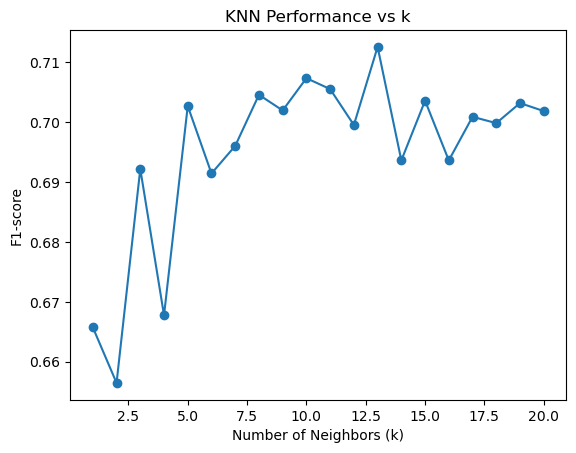

In [9]:
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

k_values = range(1, 21)
f1_scores = []

for k in k_values:
    model = Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsClassifier(n_neighbors=k))
    ])
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    f1 = f1_score(y_test, y_pred)
    f1_scores.append(f1)

plt.figure()
plt.plot(k_values, f1_scores, marker='o')
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("F1-score")
plt.title("KNN Performance vs k")
plt.show()

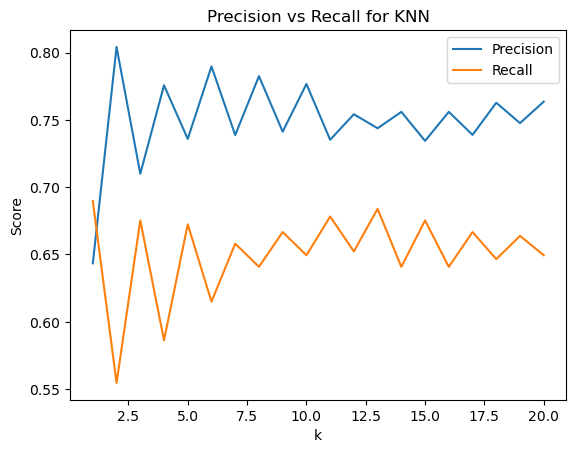

In [10]:
from sklearn.metrics import precision_score, recall_score

precision_scores = []
recall_scores = []

for k in k_values:
    model = Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsClassifier(n_neighbors=k))
    ])
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    precision_scores.append(precision_score(y_test, y_pred))
    recall_scores.append(recall_score(y_test, y_pred))

plt.figure()
plt.plot(k_values, precision_scores, label="Precision")
plt.plot(k_values, recall_scores, label="Recall")
plt.xlabel("k")
plt.ylabel("Score")
plt.title("Precision vs Recall for KNN")
plt.legend()
plt.show()

In [11]:
import pandas as pd

data = [
    ["Baseline KNN", 0.8748, 0.7358, 0.6724, 0.7027, 0.8927],
    ["KNN Grid Search", 0.8963, 0.8262, 0.6695, 0.7397, 0.9173],
    ["DTW + KNN", 0.9165, 0.8068, 0.8161, 0.8114, 0.9519],
]

columns = ["Model", "Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]

df = pd.DataFrame(data, columns=columns)

df

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Baseline KNN,0.8748,0.7358,0.6724,0.7027,0.8927
1,KNN Grid Search,0.8963,0.8262,0.6695,0.7397,0.9173
2,DTW + KNN,0.9165,0.8068,0.8161,0.8114,0.9519


У ході дослідження було проаналізовано ефективність моделі K-Nearest Neighbors для задачі прогнозування buzz на датасеті TH_500.

Базова модель KNN продемонструвала помірні результати (F1-score = 0.703), що свідчить про обмежену здатність моделі до точного розділення класів. Після оптимізації гіперпараметрів за допомогою Grid Search вдалося покращити якість моделі: F1-score зріс до 0.740, precision до 0.826, а ROC-AUC до 0.917. Однак recall залишився на відносно низькому рівні (0.670), що вказує на недостатню здатність моделі виявляти всі випадки buzz.

Аналіз залежності F1-score від кількості сусідів показав, що модель не має чітко вираженого оптимального значення параметра k, а її продуктивність коливається в невеликому діапазоні. Це свідчить про нестабільність KNN на даному наборі даних. Додатково, графік precision та recall підтверджує наявність компромісу між точністю та повнотою: при зростанні precision спостерігається зниження recall, що є характерною особливістю даного алгоритму.

Отримані результати показують, що модель KNN поступається більш складним алгоритмам, таким як Random Forest та XGBoost, що досягають значно вищих значень F1-score. Це може бути пов’язано з високою розмірністю простору ознак та складною структурою даних, у яких KNN втрачає ефективність через залежність від метрики відстані.

Таким чином, KNN не є оптимальним вибором для даної задачі і не був включений до фінального ансамблю моделей, проте його використання дозволило краще зрозуміти поведінку алгоритмів, заснованих на відстанях, у задачах з великою кількістю ознак.

### 1000

### 1.Baseline Knn

In [14]:
X = TH_1000.drop(columns=['label'])
y = TH_1000['label']

X_train, X_test, y_train, y_test = train_test_split( X, y,test_size=0.2,stratify=y,random_state=42)

pipe_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

pipe_knn.fit(X_train, y_train)

y_pred = pipe_knn.predict(X_test)
y_prob = pipe_knn.predict_proba(X_test)[:,1]

print("Baseline KNN")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

Baseline KNN
Accuracy: 0.9190385831752056
Precision: 0.75
Recall: 0.6351351351351351
F1: 0.6878048780487804
ROC-AUC: 0.8988143772911984


### 2.KNN with Grid Search

In [15]:
param_grid_knn = {
    'knn__n_neighbors': [3, 5, 7, 9, 11],
    'knn__weights': ['uniform', 'distance'],
    'knn__metric': ['euclidean', 'manhattan']
}

grid_knn = GridSearchCV(pipe_knn,param_grid_knn,cv=5,scoring='f1',n_jobs=-1)

grid_knn.fit(X_train, y_train)

best_knn = grid_knn.best_estimator_
y_pred = best_knn.predict(X_test)
y_prob = best_knn.predict_proba(X_test)[:,1]

print("\nKNN with Grid Search")
print("Best params:", grid_knn.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))


KNN with Grid Search
Best params: {'knn__metric': 'manhattan', 'knn__n_neighbors': 7, 'knn__weights': 'uniform'}
Accuracy: 0.9304237824161923
Precision: 0.8294117647058824
Recall: 0.6351351351351351
F1: 0.7193877551020408
ROC-AUC: 0.9146149460718997


In [9]:
import numpy as np
from tslearn.neighbors import KNeighborsTimeSeriesClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

X = TH_1000.drop(columns=['label'])
y = TH_1000['label']

groups = {}

for col in TH_1000.columns:
    if "_" in col and col != "label":
        parts = col.split("_")
        
        # перевіряємо що друга частина — число
        if len(parts) == 2 and parts[1].isdigit():
            prefix = parts[0]
            groups.setdefault(prefix, []).append(col)

# --- 2. Сортуємо колонки по часу ---
for key in groups:
    groups[key] = sorted(groups[key], key=lambda x: int(x.split("_")[1]))

# --- 3. Формуємо 3D масив ---
series_list = []

for prefix in groups:
    series = TH_1000[groups[prefix]].values  # (samples, time_steps)
    series_list.append(series)

# stack → (samples, time_steps, n_features)
X = np.stack(series_list, axis=2)

y = TH_1000["label"].values

print("Shape X:", X.shape)  # перевірка

# --- 4. Train/Test split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# --- 5. DTW + KNN ---
knn_dtw = KNeighborsTimeSeriesClassifier(
    n_neighbors=5,
    metric="dtw"
)

# --- 6. Тренування ---
knn_dtw.fit(X_train, y_train)

# --- 7. Передбачення ---
y_pred = knn_dtw.predict(X_test)
y_prob = knn_dtw.predict_proba(X_test)[:, 1]

# --- 8. Метрики ---
print("\nDTW + KNN (ALL TIME SERIES, TH_1000)")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

Shape X: (7905, 8, 10)

DTW + KNN (ALL TIME SERIES, TH_1000)
Accuracy: 0.9475015812776724
Precision: 0.8390243902439024
Recall: 0.7747747747747747
F1: 0.8056206088992974
ROC-AUC: 0.9454421308725944


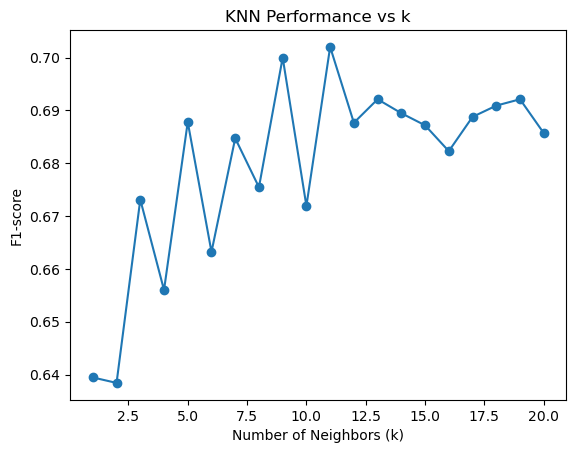

In [16]:
k_values = range(1, 21)
f1_scores = []

for k in k_values:
    model = Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsClassifier(n_neighbors=k))
    ])
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    f1 = f1_score(y_test, y_pred)
    f1_scores.append(f1)

plt.figure()
plt.plot(k_values, f1_scores, marker='o')
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("F1-score")
plt.title("KNN Performance vs k")
plt.show()

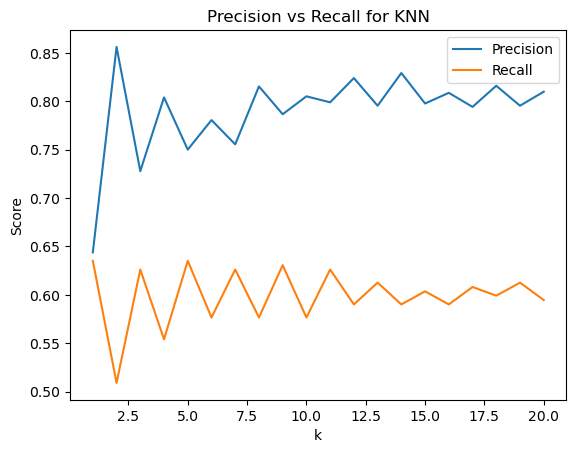

In [17]:
from sklearn.metrics import precision_score, recall_score

precision_scores = []
recall_scores = []

for k in k_values:
    model = Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsClassifier(n_neighbors=k))
    ])
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    precision_scores.append(precision_score(y_test, y_pred))
    recall_scores.append(recall_score(y_test, y_pred))

plt.figure()
plt.plot(k_values, precision_scores, label="Precision")
plt.plot(k_values, recall_scores, label="Recall")
plt.xlabel("k")
plt.ylabel("Score")
plt.title("Precision vs Recall for KNN")
plt.legend()
plt.show()

In [12]:
import pandas as pd

data = [
    ["Baseline KNN", 0.9190, 0.7500, 0.6351, 0.6878, 0.8988],
    ["KNN Grid Search", 0.9304, 0.8294, 0.6351, 0.7194, 0.9146],
    ["DTW + KNN", 0.9475, 0.8390, 0.7748, 0.8056, 0.9454],
]

columns = ["Model", "Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]

df = pd.DataFrame(data, columns=columns)

df

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Baseline KNN,0.9190,0.7500,0.6351,0.6878,0.8988
1,KNN Grid Search,0.9304,0.8294,0.6351,0.7194,0.9146
2,DTW + KNN,0.9475,0.8390,0.7748,0.8056,0.9454


У ході дослідження було проаналізовано ефективність моделі K-Nearest Neighbors для задачі прогнозування buzz на датасеті TH_1000.

Базова модель KNN продемонструвала помірні результати (F1-score = 0.688), що свідчить про обмежену здатність моделі до ефективного розділення класів. Після оптимізації гіперпараметрів за допомогою Grid Search якість моделі покращилася: F1-score зріс до 0.719, precision до 0.829, а ROC-AUC до 0.915. Водночас recall залишився без змін (0.635), що вказує на те, що оптимізація параметрів не вплинула на здатність моделі виявляти позитивний клас.

Аналіз залежності F1-score від кількості сусідів показав, що модель демонструє відносно стабільну поведінку при значеннях k у діапазоні приблизно від 8 до 15, де досягаються найкращі результати. Водночас відсутність різко вираженого максимуму свідчить про те, що модель не має чітко визначеного оптимального значення параметра k і є чутливою до вибору цього параметра.

Графік залежності precision та recall підтверджує наявність компромісу між цими метриками: зі зростанням precision значення recall залишається відносно низьким і стабільним. Це означає, що модель схильна до більш обережних передбачень і пропускає частину випадків buzz.

Отримані результати показують, що модель KNN поступається більш складним алгоритмам, таким як Random Forest та XGBoost, які демонструють значно вищі значення F1-score. Це може бути пов’язано з високою розмірністю даних та складною структурою ознак, у яких алгоритми, засновані на відстанях, працюють менш ефективно.

Таким чином, KNN не є оптимальним вибором для даного датасету і не був включений до фінального ансамблю моделей, однак його використання дозволило продемонструвати обмеження методів, заснованих на відстанях, у задачах із великою кількістю ознак.

### 1500

### 1.Baseline Knn

In [18]:
X = TH_1500.drop(columns=['label'])
y = TH_1500['label']

X_train, X_test, y_train, y_test = train_test_split( X, y,test_size=0.2,stratify=y,random_state=42)

pipe_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

pipe_knn.fit(X_train, y_train)

y_pred = pipe_knn.predict(X_test)
y_prob = pipe_knn.predict_proba(X_test)[:,1]

print("Baseline KNN")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

Baseline KNN
Accuracy: 0.9493991144845034
Precision: 0.8492063492063492
Recall: 0.6369047619047619
F1: 0.7278911564625851
ROC-AUC: 0.9283692245475684


### 2.KNN with Grid Search

In [19]:
param_grid_knn = {
    'knn__n_neighbors': [3, 5, 7, 9, 11],
    'knn__weights': ['uniform', 'distance'],
    'knn__metric': ['euclidean', 'manhattan']
}

grid_knn = GridSearchCV(pipe_knn,param_grid_knn,cv=5,scoring='f1',n_jobs=-1)

grid_knn.fit(X_train, y_train)

best_knn = grid_knn.best_estimator_
y_pred = best_knn.predict(X_test)
y_prob = best_knn.predict_proba(X_test)[:,1]

print("\nKNN with Grid Search")
print("Best params:", grid_knn.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))


KNN with Grid Search
Best params: {'knn__metric': 'manhattan', 'knn__n_neighbors': 5, 'knn__weights': 'distance'}
Accuracy: 0.9493991144845034
Precision: 0.8333333333333334
Recall: 0.6547619047619048
F1: 0.7333333333333333
ROC-AUC: 0.9395578472011592


In [13]:
import numpy as np
from tslearn.neighbors import KNeighborsTimeSeriesClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

X = TH_1500.drop(columns=['label'])
y = TH_1500['label']

groups = {}

for col in TH_1500.columns:
    if "_" in col and col != "label":
        parts = col.split("_")
        
        # перевіряємо що друга частина — число
        if len(parts) == 2 and parts[1].isdigit():
            prefix = parts[0]
            groups.setdefault(prefix, []).append(col)

# --- 2. Сортуємо колонки по часу ---
for key in groups:
    groups[key] = sorted(groups[key], key=lambda x: int(x.split("_")[1]))

# --- 3. Формуємо 3D масив ---
series_list = []

for prefix in groups:
    series = TH_1000[groups[prefix]].values  # (samples, time_steps)
    series_list.append(series)

# stack → (samples, time_steps, n_features)
X = np.stack(series_list, axis=2)

y = TH_1000["label"].values

print("Shape X:", X.shape)  # перевірка

# --- 4. Train/Test split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# --- 5. DTW + KNN ---
knn_dtw = KNeighborsTimeSeriesClassifier(
    n_neighbors=5,
    metric="dtw"
)

# --- 6. Тренування ---
knn_dtw.fit(X_train, y_train)

# --- 7. Передбачення ---
y_pred = knn_dtw.predict(X_test)
y_prob = knn_dtw.predict_proba(X_test)[:, 1]

# --- 8. Метрики ---
print("\nDTW + KNN (ALL TIME SERIES, TH_1000)")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

Shape X: (7905, 8, 10)

DTW + KNN (ALL TIME SERIES, TH_1000)
Accuracy: 0.9475015812776724
Precision: 0.8390243902439024
Recall: 0.7747747747747747
F1: 0.8056206088992974
ROC-AUC: 0.9454421308725944


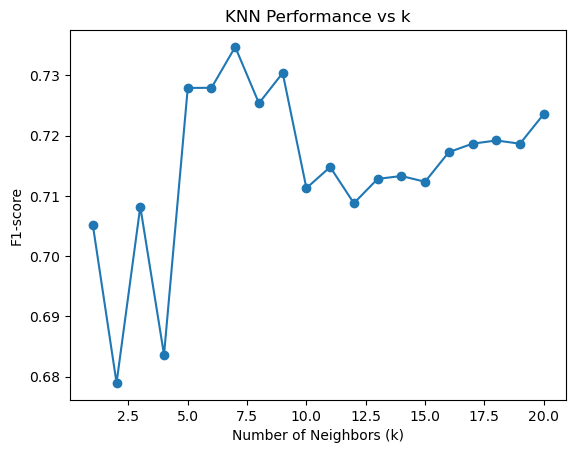

In [20]:
k_values = range(1, 21)
f1_scores = []

for k in k_values:
    model = Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsClassifier(n_neighbors=k))
    ])
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    f1 = f1_score(y_test, y_pred)
    f1_scores.append(f1)

plt.figure()
plt.plot(k_values, f1_scores, marker='o')
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("F1-score")
plt.title("KNN Performance vs k")
plt.show()

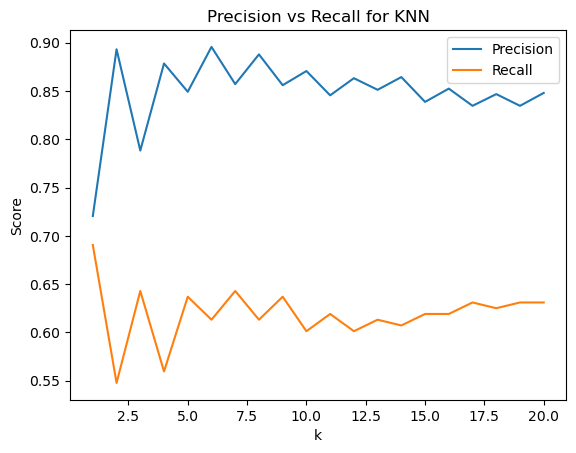

In [21]:
from sklearn.metrics import precision_score, recall_score

precision_scores = []
recall_scores = []

for k in k_values:
    model = Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsClassifier(n_neighbors=k))
    ])
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    precision_scores.append(precision_score(y_test, y_pred))
    recall_scores.append(recall_score(y_test, y_pred))

plt.figure()
plt.plot(k_values, precision_scores, label="Precision")
plt.plot(k_values, recall_scores, label="Recall")
plt.xlabel("k")
plt.ylabel("Score")
plt.title("Precision vs Recall for KNN")
plt.legend()
plt.show()

In [14]:
import pandas as pd

data = [
    ["Baseline KNN", 0.9494, 0.8492, 0.6369, 0.7279, 0.9284],
    ["KNN Grid Search", 0.9494, 0.8333, 0.6548, 0.7333, 0.9396],
    ["DTW + KNN", 0.9475, 0.8390, 0.7748, 0.8056, 0.9454],
]

columns = ["Model", "Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]

df = pd.DataFrame(data, columns=columns)

df

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Baseline KNN,0.9494,0.8492,0.6369,0.7279,0.9284
1,KNN Grid Search,0.9494,0.8333,0.6548,0.7333,0.9396
2,DTW + KNN,0.9475,0.8390,0.7748,0.8056,0.9454


У ході дослідження було проаналізовано ефективність моделі K-Nearest Neighbors для задачі прогнозування buzz на датасеті TH_1500, який характеризується найбільшою незбалансованістю класів.

Базова модель KNN продемонструвала відносно високі значення accuracy (0.949) та precision (0.849), однак recall залишився на низькому рівні (0.637), що свідчить про обмежену здатність моделі виявляти позитивний клас. Після оптимізації гіперпараметрів за допомогою Grid Search вдалося досягти незначного покращення: F1-score зріс до 0.733, recall до 0.655, а ROC-AUC до 0.940. Водночас precision дещо знизився, що відображає типовий компроміс між точністю та повнотою.

Аналіз залежності F1-score від кількості сусідів показав, що найкращі результати досягаються при невеликих значеннях k (близько 5–8), після чого якість моделі стабілізується або дещо знижується. Це свідчить про те, що для більш незбалансованих даних модель краще працює з меншою кількістю сусідів, що дозволяє точніше враховувати локальні особливості даних.

Графік залежності precision та recall підтверджує, що модель зберігає високе значення precision (близько 0.83–0.89), проте recall залишається стабільно нижчим (близько 0.60–0.65). Це означає, що KNN у даному випадку є більш консервативною моделлю, яка уникає помилкових спрацьовувань, але пропускає значну частину позитивних випадків.

Отримані результати підтверджують, що зі зростанням незбалансованості даних ефективність KNN не покращується, а модель зберігає обмежену здатність до виявлення класу buzz. У порівнянні з більш складними алгоритмами, такими як XGBoost, KNN демонструє нижчі значення F1-score та гірший баланс між precision і recall.

Таким чином, KNN не є оптимальним вибором для задачі прогнозування buzz на даному датасеті і не був включений до фінального ансамблю моделей, проте дозволив продемонструвати вплив розмірності та незбалансованості даних на ефективність алгоритмів, заснованих на відстанях.